In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.animation as manimation
from functions import get_filename
from PIL import Image

fps = 5
vminp, vmaxp = 10, 99.95


X, Y = np.loadtxt('coords.txt', unpack=True)
tot = len(X)
N = np.arange(tot)


FFMpegWriter = manimation.writers['ffmpeg']
writer = FFMpegWriter(fps=fps)

fig, ax = plt.subplots()

image = Image.open(get_filename(tot//2))
refsum = np.sum(image)
art_image = ax.imshow(image, cmap='Greys_r', vmin=np.nanpercentile(image, vminp), vmax=np.nanpercentile(image, vmaxp))


with writer.saving(fig, f"output.mp4", 100):
    for x, y, n in zip(X, Y, N):
        ax.set_title(f"n = {n}, X={x:.3f} Y={y:.3f}")
        image = Image.open(get_filename(n))
        currsum = np.sum(image)
        image = (image/currsum)*refsum
        art_image.set_array(image)

        writer.grab_frame()

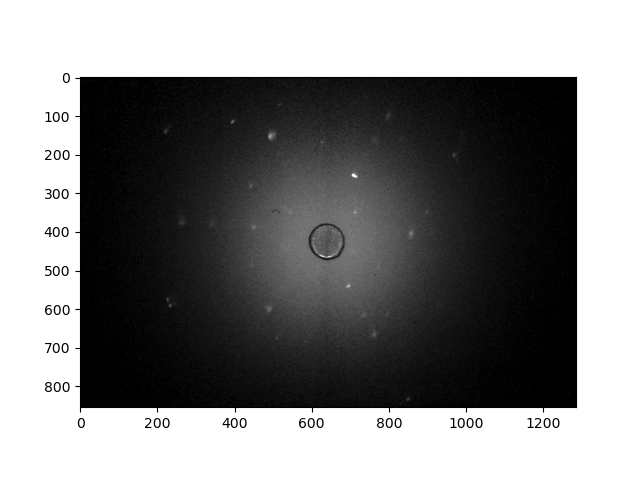

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as manimation
from functions import get_filename
from PIL import Image
%matplotlib widget

fps = 5
vminp, vmaxp = 10, 99.995


X, Y = np.loadtxt('coords.txt', unpack=True)
tot = len(X)
N = np.arange(tot)


FFMpegWriter = manimation.writers['ffmpeg']
writer = FFMpegWriter(fps=fps)

fig, ax = plt.subplots()

image = Image.open(get_filename(tot//2))  
art_image = ax.imshow(image, cmap='Greys_r', vmin=np.nanpercentile(image, vminp), vmax=np.nanpercentile(image, vmaxp))

plt.show()